# 3.2 Starting Computations

_If working on Cryocloud use at least a 32GB instance to run this notebook_

:::{admonition} Lesson Content
:class: note, dropdown

- Dataset
- Some computation
- Filtering and Masking values

:::

## Context

Yesterday we explored the data structures that `xarray` uses to organize data. Today we are going to use those data structures to manipulate data!

In [1]:
import xarray as xr
import rioxarray

## Dataset

The dataset of the day is Landsat OLI. Accessed from https://earthexplorer.usgs.gov/. This is Collection 2 Level 2.

In [2]:
from pathlib import Path

import numpy as np

In [3]:
def preprocess_function(ds):
    """
    This function assigns a new value to the `band` coordinate that corresponds
    to the band number of in the filename.
    """
    # Extract band number
    filepath = Path(ds.encoding['source'])
    band_str = filepath.stem.split('_')[-1]
    # Assign as the coordainte
    ds = ds.assign_coords(xr.Coordinates({"band": [int(band_str[1])]}))
    return ds

In [4]:
landsat = xr.open_mfdataset(
    'data/LC09_L2SP_015034_20250414_20250415_02_T1/LC09_L2SP_015034_20250414_20250415_02_T1_SR_B*.TIF',
    concat_dim='band', combine='nested', preprocess=preprocess_function,
)

This dataset is a bit bigger than the one we worked with yesterday, so the calculations (especially plotting) will take a bit longer to run.

In the code above we opened all seven bands together. A simpler thing to do would be to open a single file at a time. An example of that is below.

```python
band3 = xr.open_dataset(
    'data/LC09_L2SP_015034_20250414_20250415_02_T1/LC09_L2SP_015034_20250414_20250415_02_T1_SR_B3.TIF',
)
```

:::{admonition} 📝 Check your understanding
:class: tip

What type of data structure is the `landsat` object? What are the dimensions, how big is each one, and how many variables are there?

:::

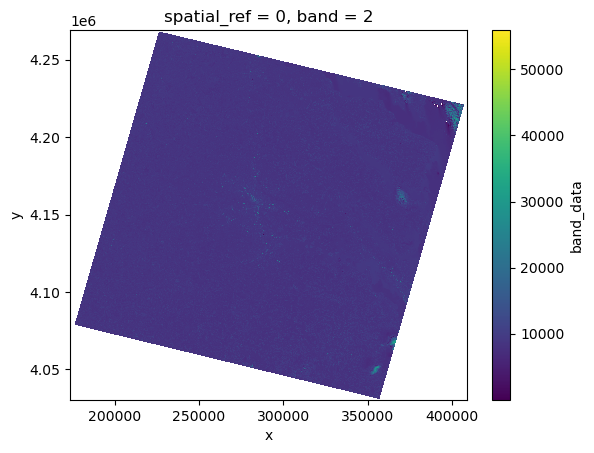

/srv/conda/envs/notebook/lib/python3.11/site-packages/dask/array/reductions.py:324: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(x_chunk, axis=axis, keepdims=keepdims)
/srv/conda/envs/notebook/lib/python3.11/site-packages/dask/array/reductions.py:291: RuntimeWarning: All-NaN slice encountered
  return np.nanmin(x_chunk, axis=axis, keepdims=keepdims)


In [5]:
landsat.sel(band=2).band_data.plot()

Notice that we have data on the edges that represents **nodata**. That means we don't have values for these areas. We can see those areas showing up as white on the plot above.

Since our dataset only has one variable in it let's simplify things but using a DataArray for the rest of the lesson.

In [6]:
landsat = landsat.band_data

## Some Computation

Let's work for a while with just the second band.

In [7]:
band2 = landsat.sel(band=2).load()

In [8]:
band2

<xarray.DataArray 'band_data' (y: 7951, x: 7841)> Size: 249MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], dtype=float32)
Coordinates:
  * x            (x) float64 63kB 1.737e+05 1.737e+05 ... 4.089e+05 4.089e+05
  * y            (y) float64 64kB 4.269e+06 4.269e+06 ... 4.031e+06 4.03e+06
    spatial_ref  int64 8B 0
    band         int64 8B 2
Attributes:
    AREA_OR_POINT:  Point

Looking at the array output we can see those nodata areas noted above represented as `nan` on the array above.

### Arithmetic

You can add / subtract / multiply / divide a DataArray by another number. Let's take a look at that using a single number in our dataset at index (5000, 5000).

In [9]:
band2.isel(x=5000, y=5000)

<xarray.DataArray 'band_data' ()> Size: 4B
array(8840., dtype=float32)
Coordinates:
    x            float64 8B 3.237e+05
    y            float64 8B 4.119e+06
    spatial_ref  int64 8B 0
    band         int64 8B 2
Attributes:
    AREA_OR_POINT:  Point

In [10]:
band2.isel(x=5000, y=5000) * 20

<xarray.DataArray 'band_data' ()> Size: 8B
array(176800.)
Coordinates:
    x            float64 8B 3.237e+05
    y            float64 8B 4.119e+06
    spatial_ref  int64 8B 0
    band         int64 8B 2

Now I understand if you aren't feeling wowed -- we basically just multiplied one number times another number. _But_ when you multiply a single number by a dataset xarray will do that multiplication for you across all the numbers in the dataset. Let's look at an example of this with what is called the **scale** and **offset** values.

It is common in remote sensing that the data that is initially read from a dataset is not the true values of the data. The values in the data file are _scalled_ and _offset_ by a certain factor from their actual value. This is done in order to make data storage more efficient. Integer numbers are smaller to store than float numbers, if we store data as integers and use a scale value to multiply it back to its original value we save space on storage.

For Surface Reflectance in this version of Landsat [the scale and offset values are](https://www.usgs.gov/faqs/how-do-i-use-a-scale-factor-landsat-level-2-science-products):

| Scale factor | Offset |
| --- | --- |
| 0.0000275 | -0.2 |

Now let's apply these to our dataset:

In [11]:
band2_scaled = (band2 * 0.0000275) - 0.2

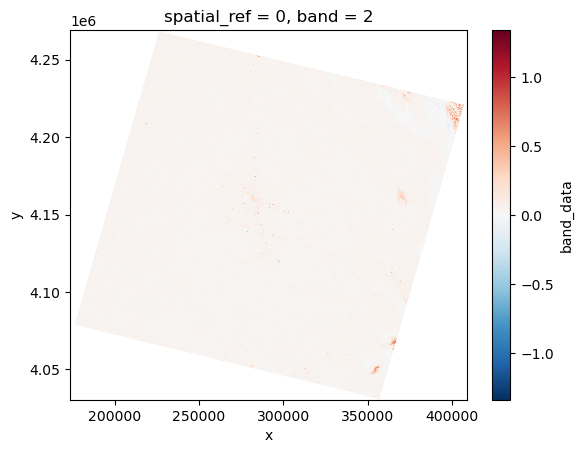

In [12]:
band2_scaled.plot()

Notice the maximum and minimum values of the color bar: -1 to 1 is a pretty different range from the 10,000 to 50,000 that was plotted on the first plot.

Does -1 to 1 make sense as a value for surface reflectance? Surface reflectance is the fraction of incoming solar radiation that is reflected back to space. Surface reflectance is a fraction, so values usually range from 0 to 1, but atmospheric corrections or other retrieval algorithms [can cause negative values](https://www.usgs.gov/faqs/why-are-negative-values-observed-over-water-some-landsat-surface-reflectance-products), particuarly over water. In summary, yes, -1 to 1 makes much more sense for this dataset than 10,000 to 50,000.

:::{admonition} 🌀 More Info: Broadcasting during arithmetic
:class: note, dropdown

The reason that this works is because numpy (and therefore xarray) uses a technique called **broadcasting**. You can read more about it [here](https://xarray-contrib.github.io/xarray-tutorial/scipy-tutorial/03_computation_with_xarray.html#Broadcasting)

:::



### Aggregations

There are a lot (a lot) of built in **methods** that manipulate data. Some common ones are:

| Function      | Description |
| ----------- | ----------- |
| `.max()`      | Maximum      |
|  `.min()`   | Minimum        |
| `.std()`    |  Standard deviation |


In [13]:
band2.max()

<xarray.DataArray 'band_data' ()> Size: 4B
array(55950., dtype=float32)
Coordinates:
    spatial_ref  int64 8B 0
    band         int64 8B 2

In [14]:
band2.min()

<xarray.DataArray 'band_data' ()> Size: 4B
array(1., dtype=float32)
Coordinates:
    spatial_ref  int64 8B 0
    band         int64 8B 2

In an earlier lesson we talked about functions/methods as verbs and attributes as adjectives when describing a data object. The methods listed above are examples of these for xarray DataArray objects!

There are a lot of methods for DataArrays. One list (of many on the internet) is [here](https://www.pythonprogramming.in/numpy-aggregate-and-statistical-functions.html).

:::{note}
One way that programming langauges grow is when people build new tools by starting with the tools that someone else already built. This accelerates progress!

You'll notice that the link above lists functions that are part of the `numpy` library. `xarray` builds on top of `numpy`, so we can use resources that others have made for numpy to help us with xarray. While not every numpy function, a lot of the numpy functions are available for xarray.

:::

:::{admonition} 📝 Check your understanding
:class: tip

What is the mean value of the sst DataArray?

:::

### Reading documentation

To practice looking at documentation, let's look at [the docs page](https://docs.xarray.dev/en/stable/generated/xarray.DataArray.max.html) for the `xarray.DataArray.max()` method.

We notice a few optional arguments - `dim` and `axis`. `dim` takes an integer as an argument and `axis` takes a string. Let's try them out.

In [15]:
band2.max(axis=1)

<xarray.DataArray 'band_data' (y: 7951)> Size: 32kB
array([nan, nan, nan, ..., nan, nan, nan], dtype=float32)
Coordinates:
  * y            (y) float64 64kB 4.269e+06 4.269e+06 ... 4.031e+06 4.03e+06
    spatial_ref  int64 8B 0
    band         int64 8B 2

In [16]:
band2.max(dim='x')

<xarray.DataArray 'band_data' (y: 7951)> Size: 32kB
array([nan, nan, nan, ..., nan, nan, nan], dtype=float32)
Coordinates:
  * y            (y) float64 64kB 4.269e+06 4.269e+06 ... 4.031e+06 4.03e+06
    spatial_ref  int64 8B 0
    band         int64 8B 2

We see that when we use these arguments instead of smushing the all the data together and taking the maximum value, we are taking the maximum value along a particular axis of data. Whatever axis we specify in the argument disappears after we take the maximum.

:::{note}
While we won't cover it here, you can use this paradigm of applying a function on a full dataset or along an axis almost indefinetly in xarray. Even if the function you want to apply isn't a built-in function (maybe it's an algorithm you wrote yourself!), you can apply it using `DataArray.reduce()`.

:::

:::{admonition} 📝 Check your understanding
:class: tip

Look at [the documentation page](https://xarray.pydata.org/en/v2022.03.0/generated/xarray.DataArray.std.html) for the `.std()` function in xarray and [the documentation page](https://numpy.org/doc/stable/reference/generated/numpy.std.html) for `.std()` in numpy.

- What does the function do? (Use the numpy page)
- Name 1 argument to the function and describe what it does.
- What type of object does the function return?

:::

## Filtering or masking values

Let's start by looking at how we use booleans with data arrays. We saw previously how we could take single values and compare them with comparisons.

In [17]:
# mask the values with ice or err set

In [18]:
7 < 10

True

In [19]:
x = 'hello'
x == 'hola'

False

Can we make boolean comparisons with xarray data? Turns out we can! We can use the same comparisons (>, <, ==, >=, <=), and it compares every value in the DataArray.

In [20]:
# import numpy as np

# np.printoptions(threshold=20)
# xr.set_options(display_expand_data=True)

In [21]:
band2.max()

<xarray.DataArray 'band_data' ()> Size: 4B
array(55950., dtype=float32)
Coordinates:
    spatial_ref  int64 8B 0
    band         int64 8B 2

In [22]:
band2 > 0.6

<xarray.DataArray 'band_data' (y: 7951, x: 7841)> Size: 62MB
array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]])
Coordinates:
  * x            (x) float64 63kB 1.737e+05 1.737e+05 ... 4.089e+05 4.089e+05
  * y            (y) float64 64kB 4.269e+06 4.269e+06 ... 4.031e+06 4.03e+06
    spatial_ref  int64 8B 0
    band         int64 8B 2

What did we get? An array of the same size where each value is a boolean True/False telling us if the condition was true.

We can even use `and` and `or` like we talked about earlier in the week, but we have to change the syntax:

* and -> `&`
* or -> `|`

In [23]:
(band2 > 0.6) & (band2 < 0.8)

<xarray.DataArray 'band_data' (y: 7951, x: 7841)> Size: 62MB
array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]])
Coordinates:
  * x            (x) float64 63kB 1.737e+05 1.737e+05 ... 4.089e+05 4.089e+05
  * y            (y) float64 64kB 4.269e+06 4.269e+06 ... 4.031e+06 4.03e+06
    spatial_ref  int64 8B 0
    band         int64 8B 2

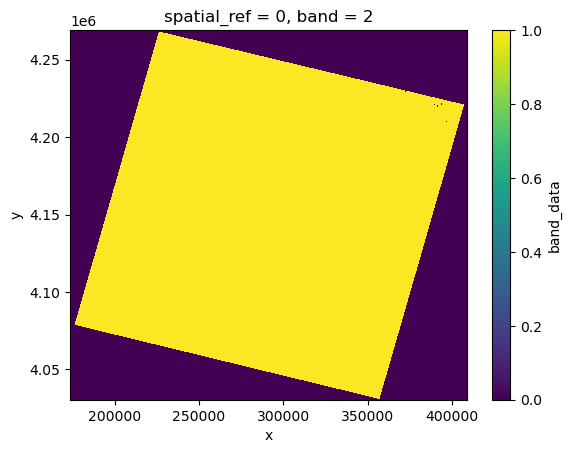

In [24]:
(band2 > 0.8).plot()

:::{admonition} 📝 Check your understanding
:class: tip

Create a plot that shows where sst is above 10 degrees.

:::

Masking values with `DataArray.where()`

In [25]:
band2.where(band2 > 0)

<xarray.DataArray 'band_data' (y: 7951, x: 7841)> Size: 249MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], dtype=float32)
Coordinates:
  * x            (x) float64 63kB 1.737e+05 1.737e+05 ... 4.089e+05 4.089e+05
  * y            (y) float64 64kB 4.269e+06 4.269e+06 ... 4.031e+06 4.03e+06
    spatial_ref  int64 8B 0
    band         int64 8B 2
Attributes:
    AREA_OR_POINT:  Point

Masking values with `xr.where()`

Another common kind of data manipulation is to want to give data cells new values based on their old values. For that we will use [`xr.where()`](https://xarray.pydata.org/en/stable/generated/xarray.where.html).

`xr.where()` takes at least three arguments:

> `xr.where(condition, true, false)`

- `condition` should be any type of boolean statement like above that returns a bunch of True/False
- `true` is what xarray should put into any place that has a True value.

Optionally, you can also add a third argument describing what would happen should happen to the places where the `condition` array is False.

**Note** better to go with the method version of .where ? https://xarray.pydata.org/en/v2022.03.0/generated/xarray.Dataset.where.html 


In this example, we see that anywhere that `sst` is greater than 20, xarray will put the word "warm".  All other places it will put the word "cold".

In [26]:
xr.where(band2 >= 0.3, "bright", "dark")

<xarray.DataArray 'band_data' (y: 7951, x: 7841)> Size: 1GB
array([['dark', 'dark', 'dark', ..., 'dark', 'dark', 'dark'],
       ['dark', 'dark', 'dark', ..., 'dark', 'dark', 'dark'],
       ['dark', 'dark', 'dark', ..., 'dark', 'dark', 'dark'],
       ...,
       ['dark', 'dark', 'dark', ..., 'dark', 'dark', 'dark'],
       ['dark', 'dark', 'dark', ..., 'dark', 'dark', 'dark'],
       ['dark', 'dark', 'dark', ..., 'dark', 'dark', 'dark']], dtype='<U6')
Coordinates:
  * x            (x) float64 63kB 1.737e+05 1.737e+05 ... 4.089e+05 4.089e+05
  * y            (y) float64 64kB 4.269e+06 4.269e+06 ... 4.031e+06 4.03e+06
    spatial_ref  int64 8B 0
    band         int64 8B 2

In [27]:
import numpy as np

In [28]:
xr.where(band2 < 0.3, np.nan, band2)

<xarray.DataArray 'band_data' (y: 7951, x: 7841)> Size: 249MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], dtype=float32)
Coordinates:
  * x            (x) float64 63kB 1.737e+05 1.737e+05 ... 4.089e+05 4.089e+05
  * y            (y) float64 64kB 4.269e+06 4.269e+06 ... 4.031e+06 4.03e+06
    spatial_ref  int64 8B 0
    band         int64 8B 2

Notice that the conditional doesn't have to be data from the original dataset - it could be one of its coordinates, or even a totally different dataset of the same shape.

In [29]:
masked = xr.where(band2.x > 300_000, 0, band2)

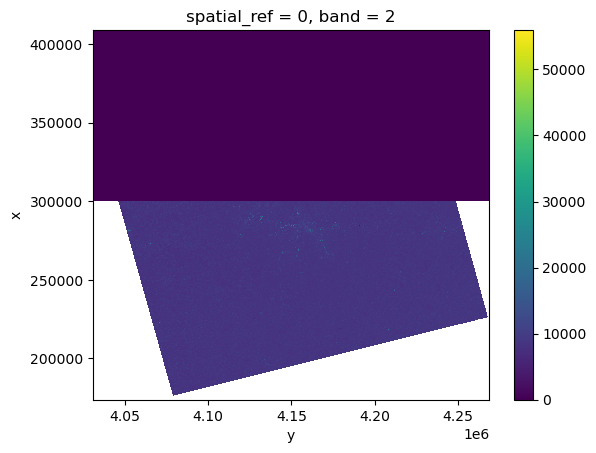

In [30]:
masked.plot()

## Putting it all together: Band Math

One very common practice in remote sensing is what is called band math. Band math is when you take different bands from the same sensor and do arithmetic on them to get something new.

Each band from Landsat shows surface reflectance from a particular wavelength of light. See [this reference](https://www.usgs.gov/faqs/what-are-band-designations-landsat-satellites).

We are going to calculated the Normalized Difference Vegetation Index or NDVI. NDVI tells us how about the amount of vegetation in our scene. NDVI uses two bands: A Red band and a near infrared band. First, let's get these two bands from our `landsat` dataset.

First, let's apply the scale and offset to our dataset:

In [31]:
landsat = landsat

In [32]:
landsat = (landsat * 0.0000275) - 0.2

Now let's extract just the bands we want:

In [33]:
red = landsat.sel(band=4).load()
nir = landsat.sel(band=5).load()

Just to make sure everything is going smoothly, let's make sure the values look reasonable:

In [34]:
red.min()

<xarray.DataArray 'band_data' ()> Size: 4B
array(-0.159135, dtype=float32)
Coordinates:
    spatial_ref  int64 8B 0
    band         int64 8B 4

In [35]:
nir.min()

<xarray.DataArray 'band_data' ()> Size: 4B
array(-0.08461, dtype=float32)
Coordinates:
    spatial_ref  int64 8B 0
    band         int64 8B 5

Recall that surface reflectance values _should_ be between 0 and 1. We can see that a few negative values are in this dataset, so let's mask them out.

In [36]:
red = red.where(red > 0)
nir = nir.where(nir > 0)

Now we are ready to use some band math and add full bands. The function for calculating NDVI is:

$ NDVI = \frac{NIR - Red}{NIR + Red}$

So, we need to add, subtract, and divide bands to calculate NDVI. xarray lets us add or subtract whole bands together.

In [37]:
(nir - red) / (nir + red)

<xarray.DataArray 'band_data' (y: 7951, x: 7841)> Size: 249MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], dtype=float32)
Coordinates:
  * x            (x) float64 63kB 1.737e+05 1.737e+05 ... 4.089e+05 4.089e+05
  * y            (y) float64 64kB 4.269e+06 4.269e+06 ... 4.031e+06 4.03e+06
    spatial_ref  int64 8B 0

Let's assign that to an output:

In [38]:
ndvi = (nir - red) / (nir + red)

## 

There we have NDVI! But did it work? Let's investigate by checking the maximum and minimum values.

In [39]:
ndvi.max()

<xarray.DataArray 'band_data' ()> Size: 4B
array(0.999817, dtype=float32)
Coordinates:
    spatial_ref  int64 8B 0

In [40]:
ndvi.min()

<xarray.DataArray 'band_data' ()> Size: 4B
array(-0.99967253, dtype=float32)
Coordinates:
    spatial_ref  int64 8B 0

Values range from -1 to 1. Looks good so far! How about making a plot?

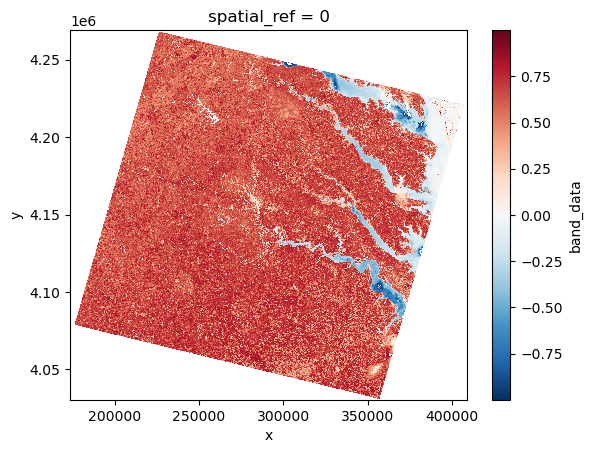

In [42]:
ndvi.plot()

Negative values are usually water, ice, and snow. Since those are rare in our scene we use the `vmin` argument to set the lowest color to 0. This helps us focus on the variability that is more common in our image.

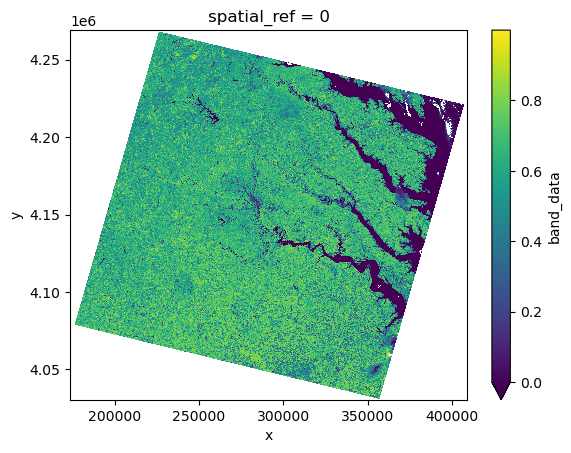

In [43]:
ndvi.plot(vmin=0)

Do you recognize the location of the image above? What is that slightly darker patch in the middle of the image (about 280,000m on the x axis and $4.15x10^6$m on the y axis)?

## Intermediate Example: Plotting a true color image

First, normalize the values so they range from -1 to 1. Normalization is:

$norm = \frac{value - min}{max - min}$

where `min` and `max` are the minimum and maximum values for the whole band.

In [44]:
landsat_norm = (landsat - landsat.min(dim=['x', 'y'])) / (landsat.max(dim=['x', 'y']) - landsat.min(dim=['x', 'y']))

In [46]:
# option 2 - one band at a time
red = landsat.sel(band=4)
green = landsat.sel(band=3)
blue = landsat.sel(band=3)

In [ ]:
# option 3 - if people know how to write functions they could write a function
# and apply it to all 3 bands

In [47]:
landsat_norm = landsat_norm.sel(band=[4, 3, 2]).load()

In [ ]:
from matplotlib.pyplot import imshow

In [ ]:
np.transpose(landsat_norm.data, (1, 2, 0)).shape

In [ ]:
imshow(np.transpose(landsat_norm.data, (1, 2, 0)))

In [ ]:
# landsat_norm.plot.imshow()

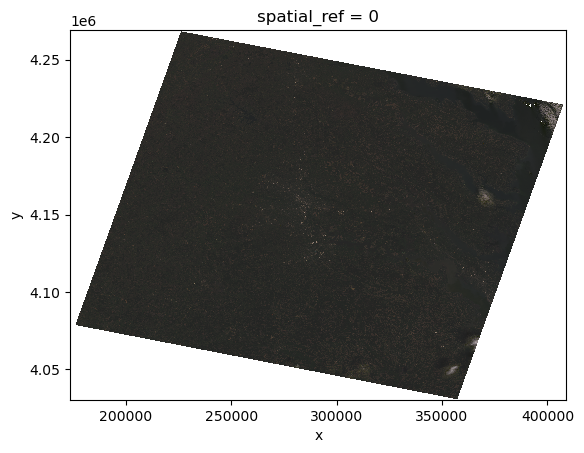

In [48]:
landsat_norm.sel(band=[4, 3, 2]).plot.imshow()